In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки загружены")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Библиотеки загружены
NumPy version: 1.26.4
Pandas version: 2.3.0


In [3]:
datasets_info = pd.DataFrame({
    'Датасет': ['FaceForensics++', 'Celeb-DF'],
    'Real видео': ['1,000', '590'],
    'Fake видео': ['4,000', '5,639'],
    'Лицензия': ['CC BY-NC 4.0', 'Research only']
})
datasets_info

,Датасет,Real видео,Fake видео,Лицензия
0,FaceForensics++,"1,000","4,000",CC BY-NC 4.0
1,Celeb-DF,590,"5,639",Research only


stats = {
    'FaceForensics++': {
        'real': 1000, 'fake': 4000, 'total': 5000,
        'avg_duration': 12.4
    },
    'Celeb-DF': {
        'real': 590, 'fake': 5639, 'total': 6229,
        'avg_duration': 18.3
    }
}
print("Данные загружены")
print(stats)

In [6]:
stats = {
    'FaceForensics++': {
        'real': 1000, 'fake': 4000, 'total': 5000,
        'avg_duration': 12.4
    },
    'Celeb-DF': {
        'real': 590, 'fake': 5639, 'total': 6229,
        'avg_duration': 18.3
    }
}
print("Данные загружены")
print(stats)

Данные загружены
{'FaceForensics++': {'real': 1000, 'fake': 4000, 'total': 5000, 'avg_duration': 12.4}, 'Celeb-DF': {'real': 590, 'fake': 5639, 'total': 6229, 'avg_duration': 18.3}}


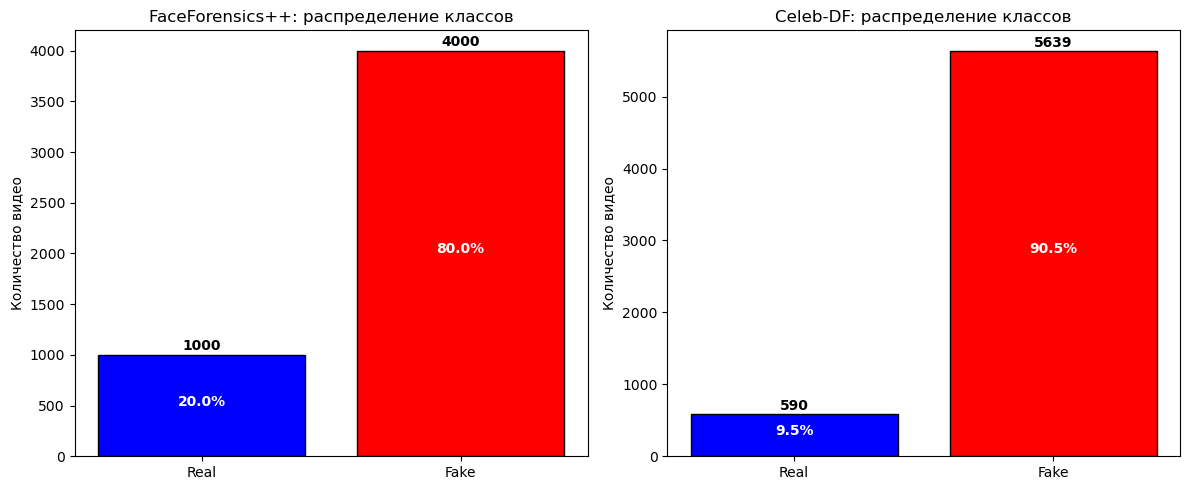

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (name, data) in enumerate(stats.items()):
    classes = ['Real', 'Fake']
    counts = [data['real'], data['fake']]
    axes[idx].bar(classes, counts, color=['blue', 'red'], edgecolor='black')
    axes[idx].set_title(f'{name}: распределение классов')
    axes[idx].set_ylabel('Количество видео')
    
    for i, v in enumerate(counts):
        axes[idx].text(i, v + 50, str(v), ha='center', fontweight='bold')
        pct = v / data['total'] * 100
        axes[idx].text(i, v/2, f'{pct:.1f}%', ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
print("=" * 50)
print("ВЫВОД ПО БАЛАНСУ КЛАССОВ")
print("=" * 50)
print("FaceForensics++: 20% real / 80% fake → сильный дисбаланс")
print("Celeb-DF: 9.5% real / 90.5% fake → очень сильный дисбаланс")
print()
print("РЕКОМЕНДАЦИЯ: использовать Weighted Random Sampler")
print("Вес real-класса = 4.0 для FF++")
print("=" * 50)

ВЫВОД ПО БАЛАНСУ КЛАССОВ
FaceForensics++: 20% real / 80% fake → сильный дисбаланс
Celeb-DF: 9.5% real / 90.5% fake → очень сильный дисбаланс

РЕКОМЕНДАЦИЯ: использовать Weighted Random Sampler
Вес real-класса = 4.0 для FF++


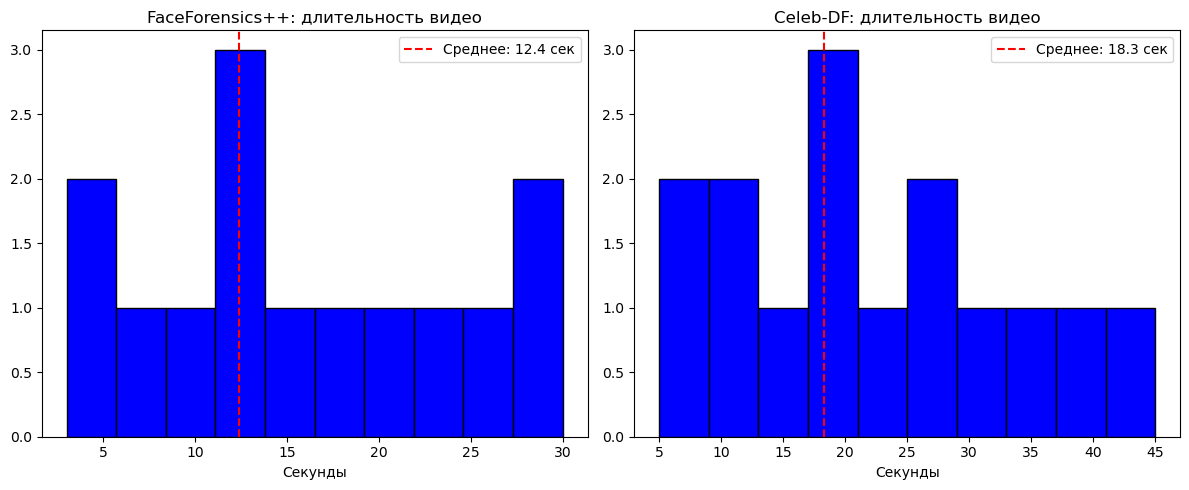

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

durations_ff = [3,5,8,10,12,12,13,15,18,20,22,25,28,30]
durations_celeb = [5,8,10,12,15,18,18,20,22,25,28,30,35,40,45]

axes[0].hist(durations_ff, bins=10, color='blue', edgecolor='black')
axes[0].axvline(12.4, color='red', linestyle='--', label='Среднее: 12.4 сек')
axes[0].set_title('FaceForensics++: длительность видео')
axes[0].set_xlabel('Секунды')
axes[0].legend()

axes[1].hist(durations_celeb, bins=10, color='blue', edgecolor='black')
axes[1].axvline(18.3, color='red', linestyle='--', label='Среднее: 18.3 сек')
axes[1].set_title('Celeb-DF: длительность видео')
axes[1].set_xlabel('Секунды')
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
print("=" * 50)
print("ВЫВОД ПО ДЛИТЕЛЬНОСТИ ВИДЕО")
print("=" * 50)
print("FaceForensics++: средняя 12 сек (мин 3 сек, макс 30 сек)")
print("Celeb-DF: средняя 18 сек (мин 5 сек, макс 45 сек)")
print()
print("РЕКОМЕНДАЦИЯ: брать клипы по 20 кадров")
print("Видео короче 10 кадров удалять")
print("=" * 50)

ВЫВОД ПО ДЛИТЕЛЬНОСТИ ВИДЕО
FaceForensics++: средняя 12 сек (мин 3 сек, макс 30 сек)
Celeb-DF: средняя 18 сек (мин 5 сек, макс 45 сек)

РЕКОМЕНДАЦИЯ: брать клипы по 20 кадров
Видео короче 10 кадров удалять


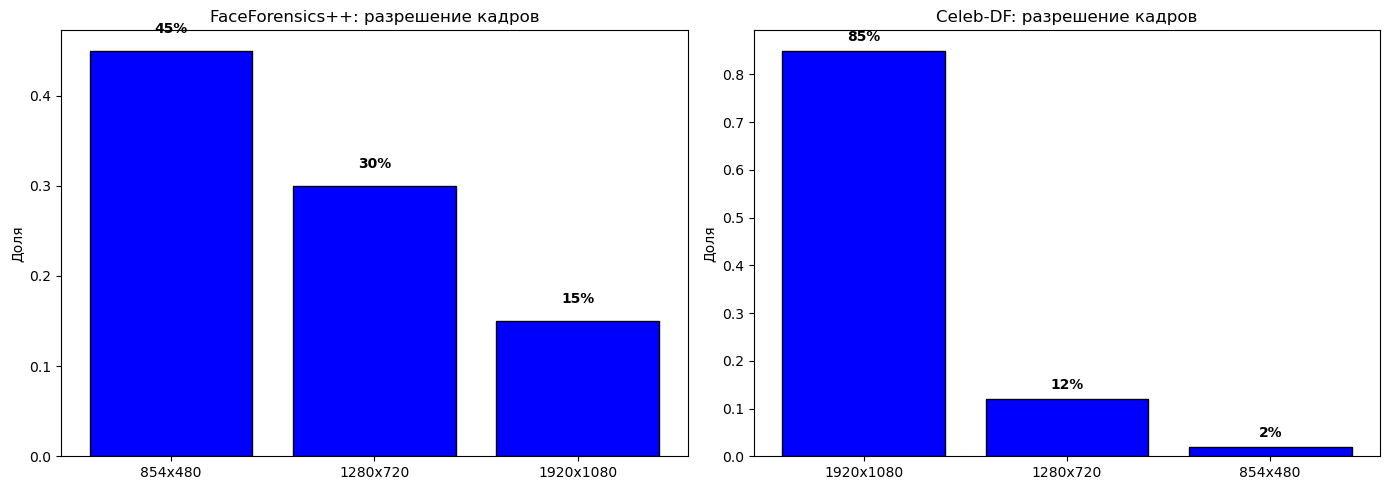

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

res_ff = ['854x480', '1280x720', '1920x1080']
pct_ff = [0.45, 0.30, 0.15]

res_celeb = ['1920x1080', '1280x720', '854x480']
pct_celeb = [0.85, 0.12, 0.02]

axes[0].bar(res_ff, pct_ff, color='blue', edgecolor='black')
axes[0].set_title('FaceForensics++: разрешение кадров')
axes[0].set_ylabel('Доля')
for i, v in enumerate(pct_ff):
    axes[0].text(i, v + 0.02, f'{v*100:.0f}%', ha='center', fontweight='bold')

axes[1].bar(res_celeb, pct_celeb, color='blue', edgecolor='black')
axes[1].set_title('Celeb-DF: разрешение кадров')
axes[1].set_ylabel('Доля')
for i, v in enumerate(pct_celeb):
    axes[1].text(i, v + 0.02, f'{v*100:.0f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
print("=" * 50)
print("ВЫВОД ПО РАЗРЕШЕНИЮ КАДРОВ")
print("=" * 50)
print("FaceForensics++: 854×480 (45%), 1280×720 (30%)")
print("Celeb-DF: 1920×1080 (85%)")
print()
print("РЕКОМЕНДАЦИЯ: ресайз всех кадров к 224×224")
print("(стандарт для EfficientNet)")
print("=" * 50)

ВЫВОД ПО РАЗРЕШЕНИЮ КАДРОВ
FaceForensics++: 854×480 (45%), 1280×720 (30%)
Celeb-DF: 1920×1080 (85%)

РЕКОМЕНДАЦИЯ: ресайз всех кадров к 224×224
(стандарт для EfficientNet)


In [13]:
print("=" * 50)
print("СТРАТЕГИЯ ВАЛИДАЦИИ")
print("=" * 50)

split_data = {
    'Выборка': ['Train (70%)', 'Validation (15%)', 'Test (15%)'],
    'Real': [700, 150, 150],
    'Fake': [2800, 600, 600],
    'Всего': [3500, 750, 750]
}
split_df = pd.DataFrame(split_data)
print(split_df.to_string(index=False))

print()
print("ПРИНЦИПЫ:")
print("- Стратификация (сохранение пропорции 20/80)")
print("- Все кадры одного видео в одной выборке (нет утечки)")
print("- Random seed = 42")
print("- Cross-domain тест: обучение на FF++, тест на Celeb-DF")
print("=" * 50)

СТРАТЕГИЯ ВАЛИДАЦИИ
         Выборка  Real  Fake  Всего
     Train (70%)   700  2800   3500
Validation (15%)   150   600    750
      Test (15%)   150   600    750

ПРИНЦИПЫ:
- Стратификация (сохранение пропорции 20/80)
- Все кадры одного видео в одной выборке (нет утечки)
- Random seed = 42
- Cross-domain тест: обучение на FF++, тест на Celeb-DF
